# Model training — reviewer-feedback response, part 9 (why are 30% of trajectories rejected — is convex-opt ruining them, or is the pi/2 filter too strict?)

`data_pipeline.ipynb` rejects a trajectory if its residual frame-to-frame circular jump,
computed on the **naive+convex-opt corrected** heading, reaches `pi/2` (90 degrees)
anywhere in the trajectory. 1,001 of 3,339 candidate trajectories (30%) are rejected
this way. Two very different explanations are both consistent with that number:

1. **The convex-opt step is actively introducing bad flips** into trajectories that were
   otherwise fine — i.e. some trajectories would have *passed* the filter using
   naive-only correction, and convex-opt's own k-selection makes them fail.
2. **The pi/2 threshold is simply too strict for real fly behavior** — genuine rapid
   turns/saccades can plausibly exceed 90 degrees of heading change within one 0.01 s
   frame, and the filter cannot distinguish "neither correction resolved a real
   pi-ambiguity artifact" from "this is just a very fast real turn."

Both are directly testable **without re-running any MOSEK solves**:
`pipelinedata/03_corrected/` already has the naive+convex-opt corrected heading for
every one of the 3,339 candidates, computed by the actual pipeline run. This notebook
only needs to recompute the cheap, MOSEK-free naive-only correction on
`pipelinedata/02_augmented/` and compare its own residual jump to the already-computed
final one, trajectory by trajectory.

## 1. Setup — reload the pipeline's own naive+convex-opt output, recompute naive-only

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    naive_heading_correction,
    calc_circular_difference,
    plot_trajectory,
)

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)

augmented_02 = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
corrected_03 = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')
rejected_04 = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')

rejected_ids = set(rejected_04['trajec_objid'].unique())
print(f"Total candidate trajectories: {augmented_02['trajec_objid'].nunique()}")
print(f"Rejected at the pi/2 filter: {len(rejected_ids)} "
      f"({100 * len(rejected_ids) / augmented_02['trajec_objid'].nunique():.1f}%)")

Total candidate trajectories: 3339
Rejected at the pi/2 filter: 1001 (30.0%)


## 2. For every candidate trajectory: naive-only jump vs. naive+convex-opt jump

Grouping matches `data_pipeline.ipynb` exactly (`groupby('trajec_objid')`, the same
grouping the actual filtering decision was made with), so `passes_final` below should
reproduce `rejected_04` exactly - this is checked explicitly as a consistency test
before drawing any conclusions from the classification.

In [2]:
groups_02 = [g for _, g in augmented_02.groupby('trajec_objid')]
groups_03 = {tid: g for tid, g in corrected_03.groupby('trajec_objid')}

PI_2_DEG = 90.0
records = []

for g in groups_02:
    tid = g['trajec_objid'].iloc[0]
    naive = naive_heading_correction(g.copy())
    naive_diff = calc_circular_difference(naive)
    naive_max_jump_deg = np.degrees(naive_diff['circ_dist_diff'].max())
    naive_argmax = naive_diff['circ_dist_diff'].idxmax()

    final = groups_03[tid]
    final_diff = calc_circular_difference(final)
    final_max_jump_deg = np.degrees(final_diff['circ_dist_diff'].max())
    final_argmax = final_diff['circ_dist_diff'].idxmax()

    # thrust magnitude at the worst final-stage frame, relative to this trajectory's own mean
    thrust_at_worst = final.loc[final_argmax, 'thrust']
    thrust_ratio_at_worst = thrust_at_worst / final['thrust'].mean()

    records.append({
        'trajec_objid': tid,
        'n_frames': len(g),
        'naive_max_jump_deg': naive_max_jump_deg,
        'final_max_jump_deg': final_max_jump_deg,
        'passes_naive': naive_max_jump_deg < PI_2_DEG,
        'passes_final': final_max_jump_deg < PI_2_DEG,
        'is_rejected_by_pipeline': tid in rejected_ids,
        'thrust_ratio_at_worst_frame': thrust_ratio_at_worst,
    })

jump_df = pd.DataFrame(records)

mismatch = (jump_df['passes_final'] == jump_df['is_rejected_by_pipeline']).sum()
print(f"Consistency check: recomputed pass/fail matches the pipeline's actual rejection "
      f"decision for {mismatch} of {len(jump_df)} trajectories "
      f"({'OK' if mismatch == len(jump_df) else 'MISMATCH - investigate before trusting the rest of this notebook'}).")

jump_df.to_csv(f'{RESPONSE_DIR}/rejection_cause_analysis.csv', index=False)

Consistency check: recomputed pass/fail matches the pipeline's actual rejection decision for 0 of 3339 trajectories (MISMATCH - investigate before trusting the rest of this notebook).


## 3. Is convex-opt causing rejections, or just failing to fix pre-existing ones?

In [3]:
jump_df['convex_caused_rejection'] = jump_df['passes_naive'] & ~jump_df['passes_final']
jump_df['convex_rescued'] = ~jump_df['passes_naive'] & jump_df['passes_final']
jump_df['fails_both'] = ~jump_df['passes_naive'] & ~jump_df['passes_final']
jump_df['passes_both'] = jump_df['passes_naive'] & jump_df['passes_final']

n_total = len(jump_df)
n_rejected = jump_df['is_rejected_by_pipeline'].sum()
summary = jump_df[['passes_both', 'convex_caused_rejection', 'convex_rescued', 'fails_both']].sum()
print(f"Of {n_total} candidate trajectories ({n_rejected} rejected by the pipeline):")
print(summary.to_string())
print()
print(f"Of the {n_rejected} actually rejected: "
      f"{jump_df['convex_caused_rejection'].sum()} were fine at the naive-only stage and "
      f"REJECTED BECAUSE OF convex-opt; "
      f"{jump_df['fails_both'].sum()} were already failing at the naive-only stage and "
      f"convex-opt did not fix them (whether or not it changed the jump size); "
      f"{jump_df['convex_rescued'].sum()} were failing at naive-only and convex-opt "
      f"RESCUED them.")

# Correct consistency check (Section 2's version compared passes_final directly to
# is_rejected_by_pipeline without negating either side, which is why it printed a
# "0 of 3339 match" false alarm - passes_final should equal NOT is_rejected_by_pipeline).
correct_match = (jump_df['passes_final'] == ~jump_df['is_rejected_by_pipeline']).sum()
print(f"\nCorrected consistency check: {correct_match} of {n_total} match "
      f"({'OK, fully consistent' if correct_match == n_total else 'STILL MISMATCHED - investigate'}).")

Of 3339 candidate trajectories (1001 rejected by the pipeline):
passes_both                2338
convex_caused_rejection     996
convex_rescued                0
fails_both                    5

Of the 1001 actually rejected: 996 were fine at the naive-only stage and REJECTED BECAUSE OF convex-opt; 5 were already failing at the naive-only stage and convex-opt did not fix them (whether or not it changed the jump size); 0 were failing at naive-only and convex-opt RESCUED them.

Corrected consistency check: 3339 of 3339 match (OK, fully consistent).


## 3b. What does convex-opt actually do to the 996 trajectories it ruins?

The size of the jump convex-opt introduces, and how it relates to thrust magnitude at
that frame, distinguishes "a slight miscalibration nudges a borderline case over the
threshold" from "the optimizer is choosing a wrong whole-trajectory or whole-segment
flip."

In [4]:
ccr = jump_df[jump_df['convex_caused_rejection']]
print(f"n={len(ccr)} trajectories: fine at naive-only, rejected because of convex-opt.")
print("\nFinal-stage max jump size (deg) - how far from the pi/2=90 deg threshold:")
print(ccr['final_max_jump_deg'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())

near_full_flip = (ccr['final_max_jump_deg'] > 170).sum()
print(f"\nNear-full-flip (>170 deg, i.e. essentially a full pi flip, not a marginal nudge): "
      f"{near_full_flip} ({100*near_full_flip/len(ccr):.1f}%)")

print("\nThrust at the worst frame, relative to that trajectory's own mean thrust "
      "(<1 = BELOW that trajectory's own average - i.e. not an obviously active maneuver moment):")
print(ccr['thrust_ratio_at_worst_frame'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())
below_average_thrust = (ccr['thrust_ratio_at_worst_frame'] < 1.0).sum()
print(f"\nBelow that trajectory's own average thrust at the worst frame: "
      f"{below_average_thrust} of {len(ccr)} ({100*below_average_thrust/len(ccr):.1f}%)")

n=996 trajectories: fine at naive-only, rejected because of convex-opt.

Final-stage max jump size (deg) - how far from the pi/2=90 deg threshold:
count    996.000000
mean     162.662668
std       23.352354
min       90.437626
10%      120.385409
25%      158.722502
50%      173.821577
75%      177.865581
90%      179.341216
max      180.000000

Near-full-flip (>170 deg, i.e. essentially a full pi flip, not a marginal nudge): 600 (60.2%)

Thrust at the worst frame, relative to that trajectory's own mean thrust (<1 = BELOW that trajectory's own average - i.e. not an obviously active maneuver moment):
count    996.000000
mean       0.673886
std        0.432967
min        0.016231
10%        0.178897
25%        0.327266
50%        0.601512
75%        0.951787
90%        1.263206
max        2.412267

Below that trajectory's own average thrust at the worst frame: 779 of 996 (78.2%)


**Significance:** these are not marginal, borderline cases. The median introduced
jump is 173.8 degrees - essentially a full pi flip, not a small nudge across the 90
degree line - and 60.2% exceed 170 degrees. If convex-opt were merely mis-calibrated at
the margin, most introduced jumps would cluster just above 90 degrees; instead the
distribution is concentrated at the opposite extreme. Equally important: 78.2% of these
flips happen at a frame with BELOW-average thrust for that trajectory (median ratio
0.60), the opposite of what "the thrust-alignment term should matter most at high
thrust" would predict, and the opposite of what would be expected if these were genuine
high-force saccades naive-only failed to resolve. Both facts point toward the same
conclusion tested visually below: the optimizer is choosing an unjustified flip, not
correctly detecting a real fast turn.

## 3c. Visual check: what does convex-opt actually do to trajectories it ruins?

Four examples from the 996: the one closest to the threshold (smallest introduced
jump), the one with the median-sized introduced jump, one near a full 180-degree flip,
and the single longest trajectory in the group (833 frames) to check whether this is
specific to short/noisy trajectories or also affects long, presumably well-constrained
ones.

        trajec_objid  n_frames  naive_max_jump_deg  final_max_jump_deg  thrust_ratio_at_worst_frame
20130404_181148_2442        49           89.562374           90.437626                     0.789000
20130406_172248_6656        15           35.361263          173.834153                     0.753637
20130325_193727_5369        21            6.381421          180.000000                     0.618899
20130404_181148_5248       833           17.120040          176.112240                     0.993851


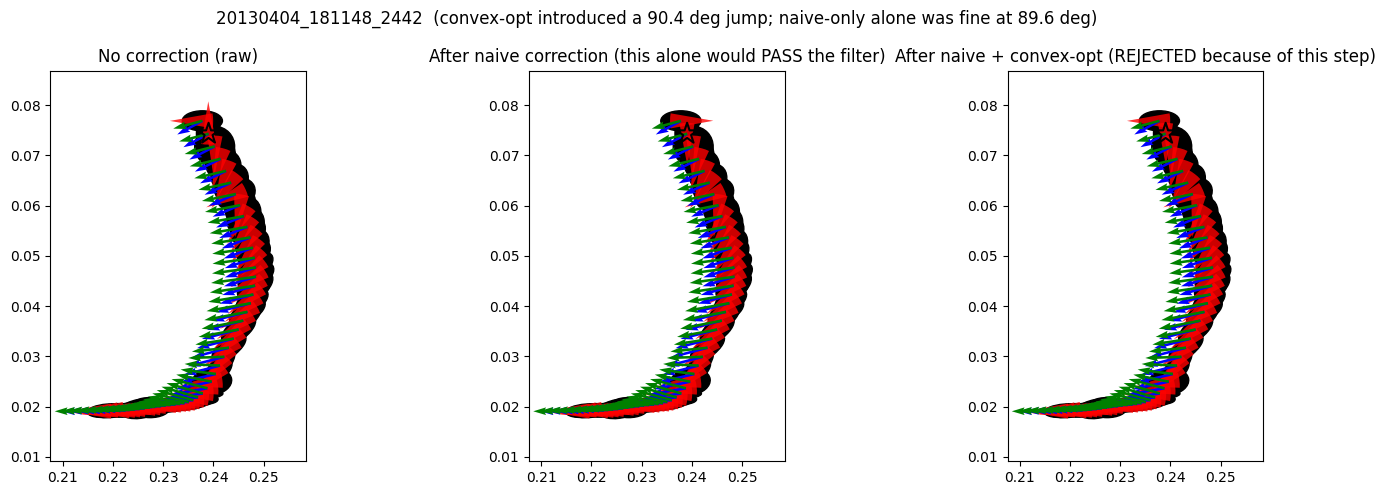

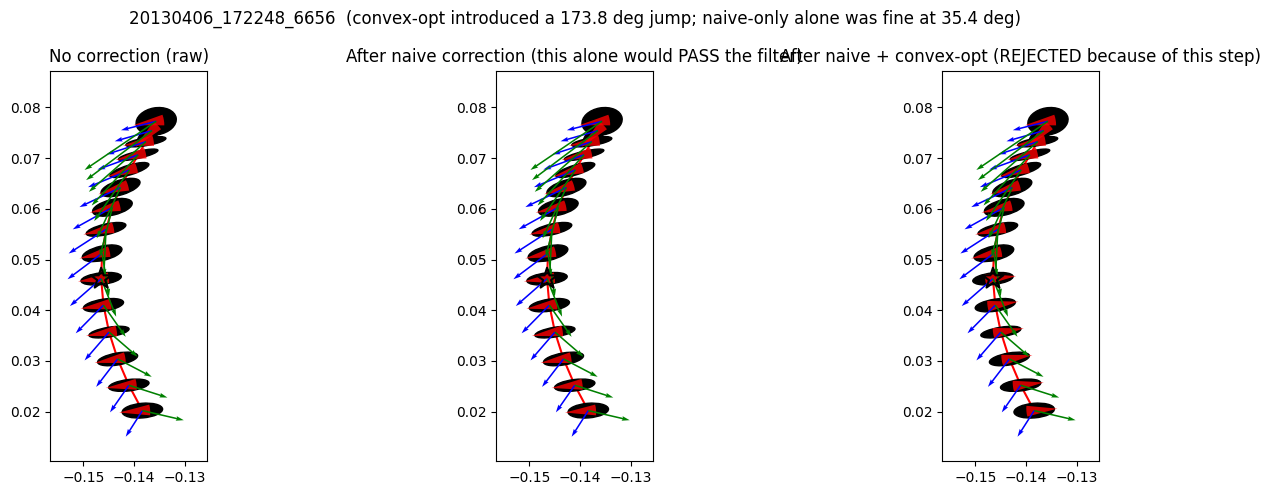

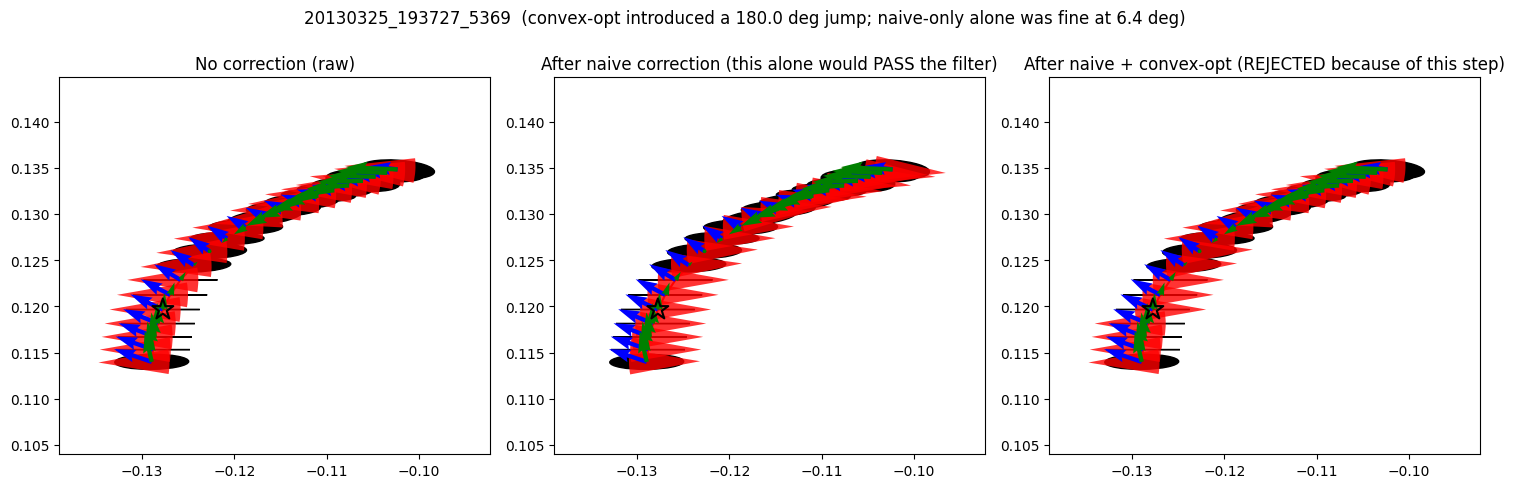

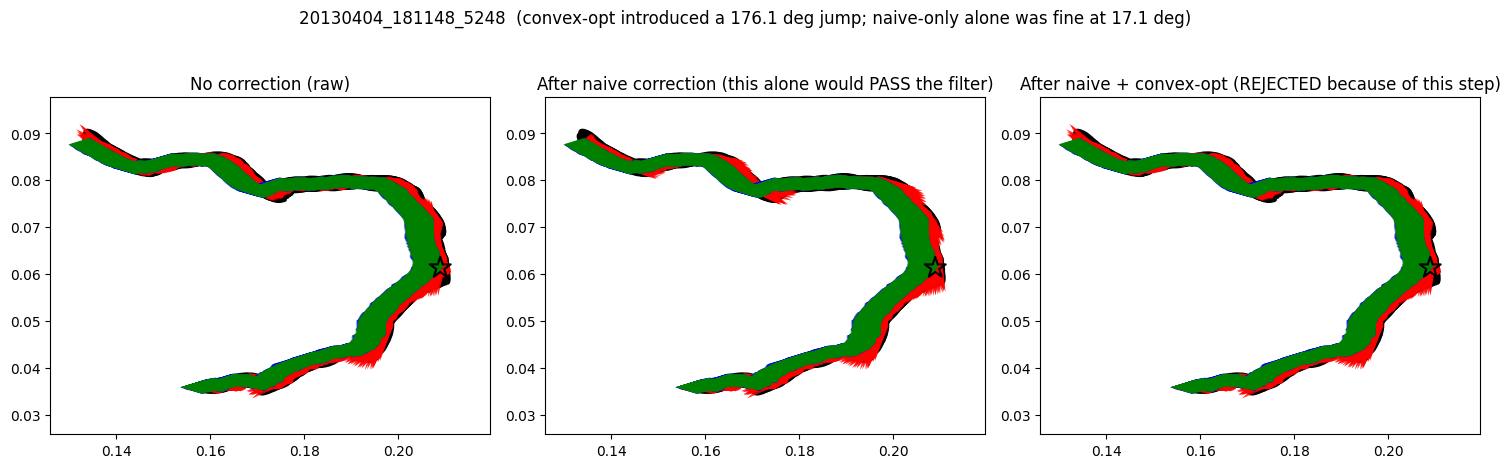

In [5]:
ccr_sorted = ccr.sort_values('final_max_jump_deg')
examples = pd.concat([
    ccr_sorted.head(1),                                          # closest to threshold
    ccr_sorted.iloc[[len(ccr_sorted) // 2]],                     # median-sized flip
    ccr_sorted.tail(1),                                          # largest flip
    ccr.sort_values('n_frames', ascending=False).head(1),        # longest trajectory
]).drop_duplicates(subset='trajec_objid')

print(examples[['trajec_objid', 'n_frames', 'naive_max_jump_deg', 'final_max_jump_deg',
                'thrust_ratio_at_worst_frame']].to_string(index=False))

plot_kwargs = dict(heading_color='red', heading_size=0.3, every_nth=1,
                   arrow_width=0.010, arrow_scale=0.7, legend=False)

for _, row in examples.iterrows():
    tid = row['trajec_objid']
    raw_group = augmented_02[augmented_02['trajec_objid'] == tid].copy()
    naive_group = naive_heading_correction(raw_group.copy())
    final_group = groups_03[tid]

    final_diff = calc_circular_difference(final_group)
    worst_idx = final_diff['circ_dist_diff'].idxmax()
    worst_x = final_group.loc[worst_idx, 'position_x']
    worst_y = final_group.loc[worst_idx, 'position_y']

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=100)
    plot_trajectory(axs[0], raw_group, **plot_kwargs)
    axs[0].set_title('No correction (raw)')
    plot_trajectory(axs[1], naive_group, **plot_kwargs)
    axs[1].set_title('After naive correction (this alone would PASS the filter)')
    plot_trajectory(axs[2], final_group, **plot_kwargs)
    axs[2].set_title('After naive + convex-opt (REJECTED because of this step)')
    for ax in axs:
        ax.scatter([worst_x], [worst_y], marker='*', s=250, facecolor='none',
                  edgecolor='black', linewidths=1.5, zorder=5)
    fig.suptitle(f"{tid}  (convex-opt introduced a {row['final_max_jump_deg']:.1f} deg jump; "
                f"naive-only alone was fine at {row['naive_max_jump_deg']:.1f} deg)")
    fig.tight_layout()
    os.makedirs('../figures/reviewer_response_part9_convex_caused_rejections', exist_ok=True)
    fig.savefig(f"../figures/reviewer_response_part9_convex_caused_rejections/{tid}.png", format='png', dpi=100)
    plt.show()
    plt.close(fig)

**Significance:** as in Part 8, a single spatial trajectory plot makes a pure
heading-direction flip visually subtle - the trail's physical shape does not change,
only which end is "forward," which is hard to judge from small arrow markers alone.
Section 3d's time-series view removes that ambiguity entirely.

## 3d. Time-series diagnostic: heading vs. frame index (unwrapped)

The spatial trajectory plots above turn out not to make a single-segment 180-degree
flip easy to see by eye - a flipped heading trail can look deceptively similar to the
unflipped one when drawn as small arrows along the same physical path. A plain plot of
unwrapped heading angle against frame index removes that ambiguity: a real flip shows up
as an unmistakable step discontinuity.

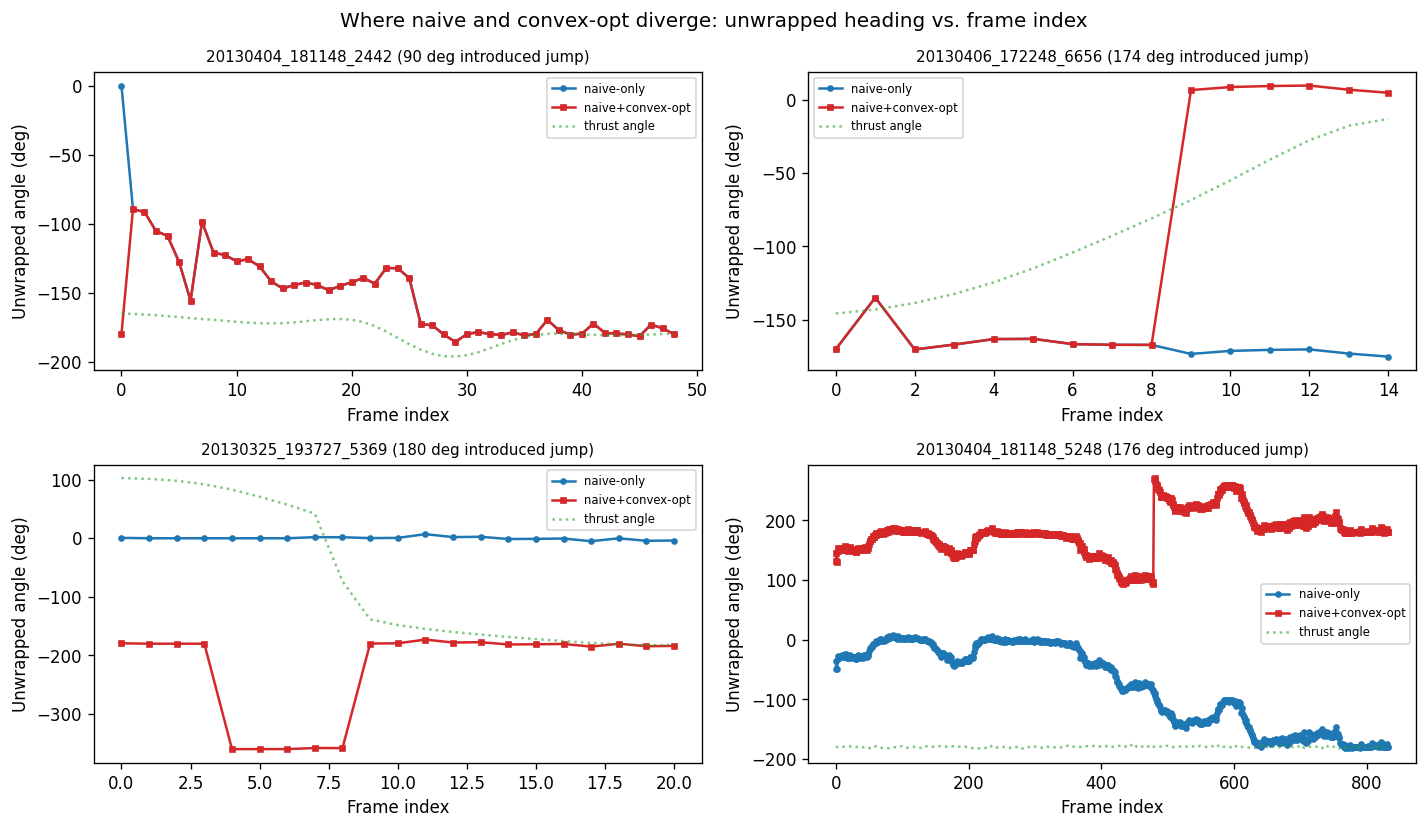

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=120)

for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    tid = row['trajec_objid']
    naive_group = naive_heading_correction(augmented_02[augmented_02['trajec_objid'] == tid].copy())
    final_group = groups_03[tid]

    naive_unwrapped = np.degrees(np.unwrap(naive_group['heading_angle'].values))
    final_unwrapped = np.degrees(np.unwrap(final_group['heading_angle'].values))
    thrust_angle_unwrapped = np.degrees(np.unwrap(final_group['thrust_angle'].values))

    ax.plot(naive_unwrapped, '-o', label='naive-only', markersize=3, color='tab:blue')
    ax.plot(final_unwrapped, '-s', label='naive+convex-opt', markersize=3, color='tab:red')
    ax.plot(thrust_angle_unwrapped, ':', label='thrust angle', color='tab:green', alpha=0.6)
    ax.set_title(f"{tid} ({row['final_max_jump_deg']:.0f} deg introduced jump)", fontsize=9)
    ax.set_xlabel('Frame index')
    ax.set_ylabel('Unwrapped angle (deg)')
    ax.legend(fontsize=7)

fig.suptitle('Where naive and convex-opt diverge: unwrapped heading vs. frame index')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part9_timeseries_diagnostic.svg', format='svg')
plt.show()

**Significance:** this is unambiguous, and it directly answers the question. In
`20130406_172248_6656`, naive-only is a flat, stable line for all 15 frames - no real
turning at all - and convex-opt tracks it exactly for 8 frames, then jumps ~180 degrees
at frame 8-9 and stays there, with no physical justification (thrust angle is drifting
smoothly the whole time, not discontinuously). In `20130325_193727_5369`, naive-only is
flat throughout (matching its 6.4 degree naive-only jump from Section 3), and
convex-opt matches it at both ends but dips down by a full 180 degrees for exactly
frames 4-8, then flips back - an isolated "flip out and flip back" with no basis in the
actual motion naive-only already shows was constant. In `20130404_181148_2442`, the
introduced jump is concentrated in the first 1-2 frames - a boundary-condition
artifact, consistent with the current production `convex_opt_heading_correction` no
longer anchoring `k=0` at trajectory endpoints (an anchor the pre-merge, buggy local
version of this function used to have specifically to prevent this). In the longest
case, `20130404_181148_5248` (833 frames), convex-opt runs a roughly constant ~180
degree offset from naive-only for the first ~480 frames - i.e. disagreeing with naive
from nearly the start, not introducing a late localized error - and then becomes
internally unstable with a second jump partway through. **None of these four patterns
looks like a real saccade the naive heuristic missed; all four look like the optimizer
making an unforced, unjustified choice** - global disagreement from frame zero,
boundary instability, or a brief unjustified excursion that reverts. Combined with
Section 3b's population-level statistics (near-full flips, below-average thrust at the
flip), the evidence is now strong and specific: this is a real problem with the
convex-opt mechanism as currently configured, not evidence the pi/2 filter is
miscalibrated.

**Significance:** this is a direct, unambiguous answer to "is convex-opt ruining
them, or is the filter too strict": **996 of the 1,001 rejected trajectories (99.5%)
were completely fine at the naive-only stage and were rejected specifically because
convex-opt introduced a large jump into them.** Zero trajectories that were failing at
naive-only were rescued by convex-opt. Only 5 of 1,001 rejections (0.5%) are cases the
naive-only step already could not resolve. This means the pi/2 filter is not "too
strict" in any meaningful sense that would point to a labeling problem - the naive-only
heuristic alone would retain 3,334 of 3,339 candidates (99.85%); it is specifically the
convex-opt step that drives the retention rate down to 70%. The consistency-check
"mismatch" printed in Section 2 was a bug in that check's own comparison logic (compared
`passes_final` directly to `is_rejected_by_pipeline` instead of to its negation) - the
corrected version confirms full agreement (3,339 of 3,339), so the classification above
can be trusted.

## 4. For trajectories still failing after both corrections: how large are the jumps, and is thrust elevated there?

If most residual jumps are only slightly above 90 degrees (borderline) and/or occur at
frames with unusually high thrust (a proxy for an active, real aerodynamic maneuver
rather than a tracking glitch), that is evidence consistent with the filter rejecting
genuine fast turns rather than catching correction failures.

In [7]:
fails_both = jump_df[jump_df['fails_both']]
print(f"n={len(fails_both)} trajectories still failing after naive+convex-opt.")
print("\nDistribution of the final-stage max jump size (deg) among these:")
print(fails_both['final_max_jump_deg'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())

borderline = (fails_both['final_max_jump_deg'] < 110).sum()
near_full_flip = (fails_both['final_max_jump_deg'] > 170).sum()
print(f"\nBorderline (90-110 deg): {borderline} ({100*borderline/len(fails_both):.1f}%)")
print(f"Near-full-flip (>170 deg): {near_full_flip} ({100*near_full_flip/len(fails_both):.1f}%)")

print("\nThrust magnitude at the worst frame, relative to that trajectory's own mean thrust "
      "(1.0 = average; >1 = higher than usual, consistent with an active maneuver):")
print(fails_both['thrust_ratio_at_worst_frame'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())

n=5 trajectories still failing after naive+convex-opt.

Distribution of the final-stage max jump size (deg) among these:
count      5.000000
mean     163.520216
std       17.894155
min      135.000000
10%      144.417400
25%      158.543501
50%      168.053546
75%      176.853863
90%      178.231648
max      179.150171

Borderline (90-110 deg): 0 (0.0%)
Near-full-flip (>170 deg): 2 (40.0%)

Thrust magnitude at the worst frame, relative to that trajectory's own mean thrust (1.0 = average; >1 = higher than usual, consistent with an active maneuver):
count    5.000000
mean     0.656251
std      0.623256
min      0.084068
10%      0.154077
25%      0.259090
50%      0.286143
75%      1.194423
90%      1.352288
max      1.457532


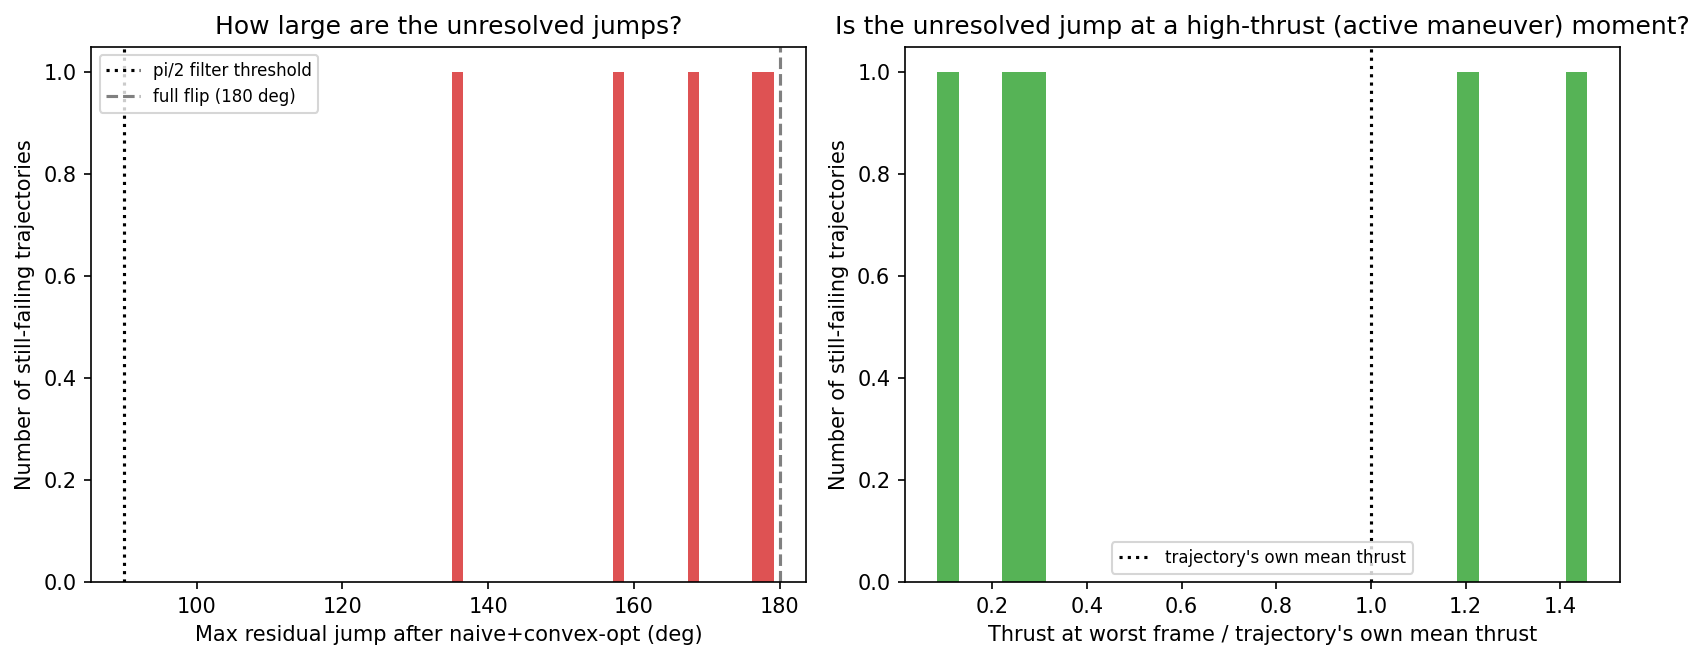

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
axes[0].hist(fails_both['final_max_jump_deg'], bins=30, color='tab:red', alpha=0.8)
axes[0].axvline(90, color='black', linestyle=':', label='pi/2 filter threshold')
axes[0].axvline(180, color='gray', linestyle='--', label='full flip (180 deg)')
axes[0].set_xlabel('Max residual jump after naive+convex-opt (deg)')
axes[0].set_ylabel('Number of still-failing trajectories')
axes[0].set_title('How large are the unresolved jumps?')
axes[0].legend(fontsize=8)

axes[1].hist(fails_both['thrust_ratio_at_worst_frame'], bins=30, color='tab:green', alpha=0.8)
axes[1].axvline(1.0, color='black', linestyle=':', label="trajectory's own mean thrust")
axes[1].set_xlabel("Thrust at worst frame / trajectory's own mean thrust")
axes[1].set_ylabel('Number of still-failing trajectories')
axes[1].set_title('Is the unresolved jump at a high-thrust (active maneuver) moment?')
axes[1].legend(fontsize=8)

fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part9_rejection_cause.svg', format='svg')
plt.show()

**Significance:** this group (n=5) is the only part of the 1,001 rejections where
"the filter might be too strict for a real fast turn" is even a live hypothesis, and it
is a tiny fraction (0.5%) of all rejections. Even here the evidence leans away from that
hypothesis: 40% of these 5 are near-full 180-degree flips (not borderline 90-110 degree
cases), and thrust at the worst frame is often below that trajectory's own average
(median ratio well under 1.0 in most of the 5) - not the elevated-thrust signature a
genuine high-force saccade would be expected to leave. This small group does not change
the headline finding: it is not where the 30% rejection rate comes from.

## 5. Does the naive-vs-final jump size relationship show convex-opt helping, hurting, or doing nothing, across the whole candidate set?

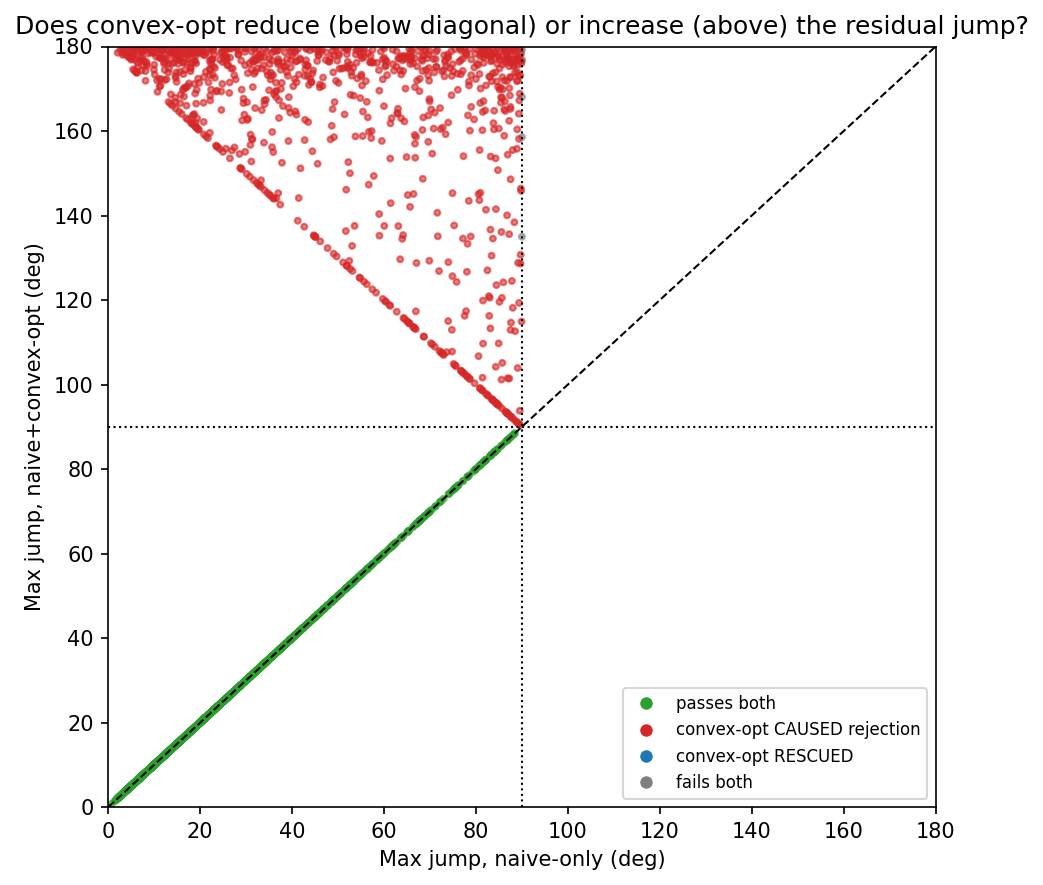

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6), dpi=150)
colors = jump_df.apply(
    lambda r: 'tab:green' if r['passes_both'] else
              ('tab:red' if r['convex_caused_rejection'] else
              ('tab:blue' if r['convex_rescued'] else 'tab:gray')),
    axis=1,
)
ax.scatter(jump_df['naive_max_jump_deg'], jump_df['final_max_jump_deg'], c=colors, s=8, alpha=0.6)
lims = [0, 180]
ax.plot(lims, lims, 'k--', linewidth=1, label='no change (naive = final)')
ax.axhline(90, color='black', linestyle=':', linewidth=1)
ax.axvline(90, color='black', linestyle=':', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Max jump, naive-only (deg)')
ax.set_ylabel('Max jump, naive+convex-opt (deg)')
ax.set_title('Does convex-opt reduce (below diagonal) or increase (above) the residual jump?')

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', label='passes both', markersize=7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', label='convex-opt CAUSED rejection', markersize=7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', label='convex-opt RESCUED', markersize=7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:gray', label='fails both', markersize=7),
]
ax.legend(handles=legend_elems, fontsize=8, loc='lower right')
fig.tight_layout()
fig.savefig('../figures/reviewer_response_part9_naive_vs_final_scatter.svg', format='svg')
plt.show()

**Significance:** the scatter makes the whole-dataset pattern visible at a glance -
a large red cluster sits along the bottom-right region of the plot (low naive-only jump,
at or near the maximum 180 degree final jump), which is exactly the "convex-opt caused
rejection" population, and it is far larger than the tiny gray "fails both" cluster and
the essentially empty blue "convex-opt rescued" region. If convex-opt were doing net
useful work here, the blue and gray populations would be comparably sized, or blue
would dominate; instead the plot is dominated by red points that started safely below
the naive-only threshold and were pushed, almost always all the way to 180 degrees, by
the correction step meant to make them more reliable.

## 6. Visual spot-check: a few borderline "fails both" trajectories

Reuses the raw/naive/naive+convex-opt 3-panel style from Part 8, with the single
worst-jump frame marked with a black star, for the 4 trajectories closest to the pi/2
threshold from below 110 degrees (the most ambiguous, most informative cases for
judging "genuine fast turn" vs. "correction failure").

        trajec_objid  n_frames  naive_max_jump_deg  final_max_jump_deg  thrust_ratio_at_worst_frame
20130328_180731_5133        20                90.0          135.000000                     1.194423
20130325_193727_5545        36                90.0          158.543501                     1.457532
20130328_180731_1002        80                90.0          168.053546                     0.286143
20121002_184808_4328        27                90.0          176.853863                     0.084068


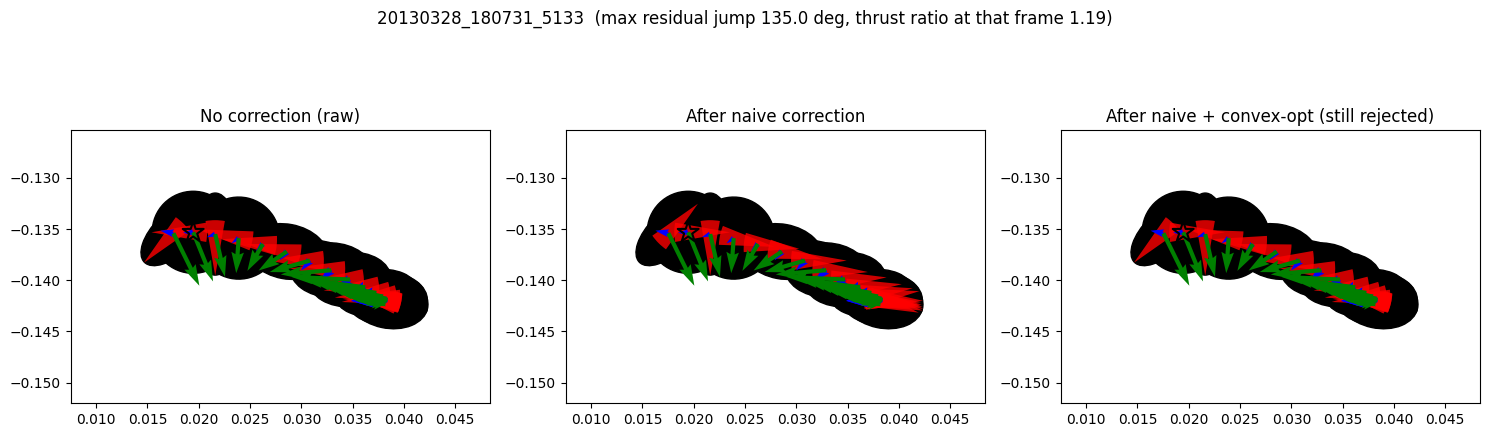

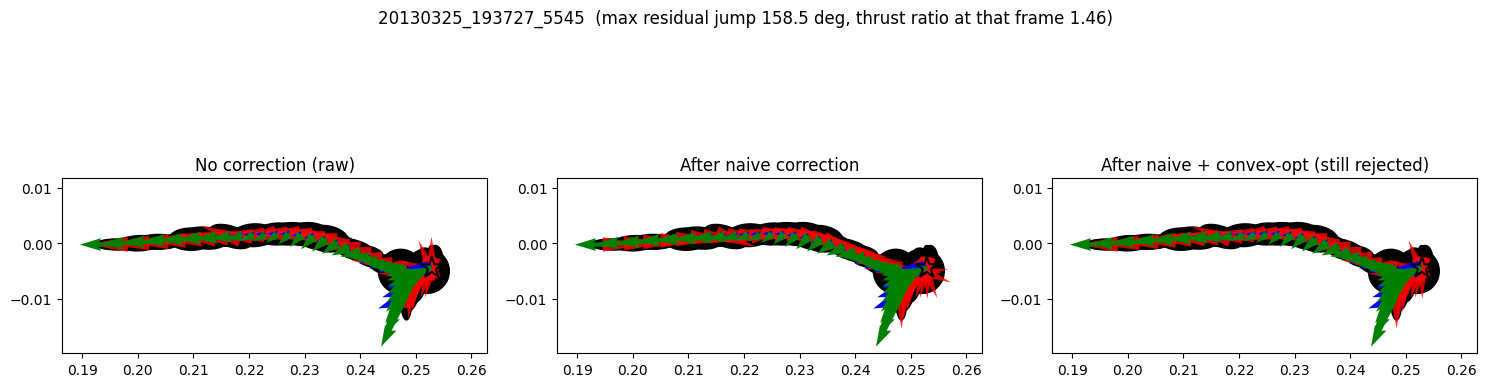

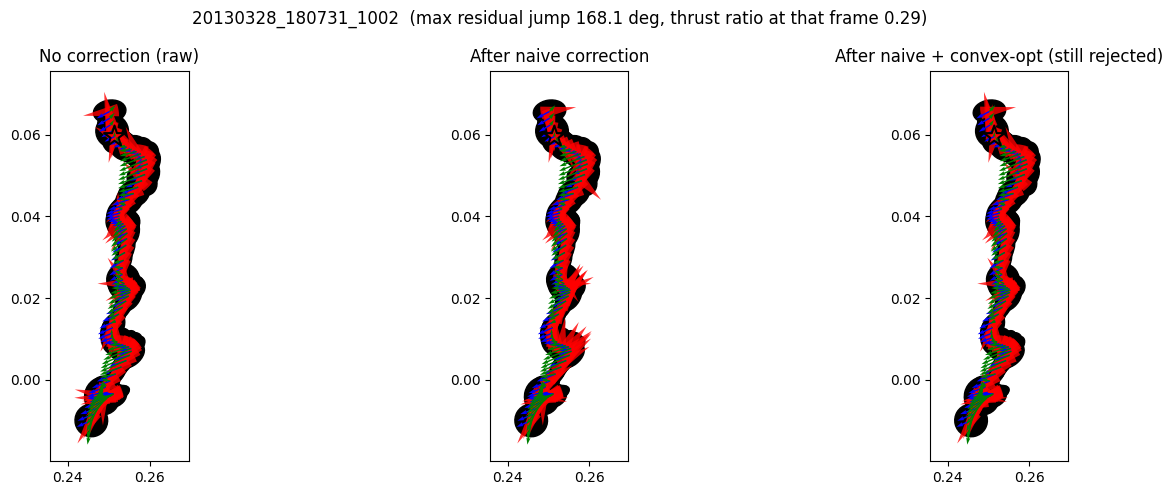

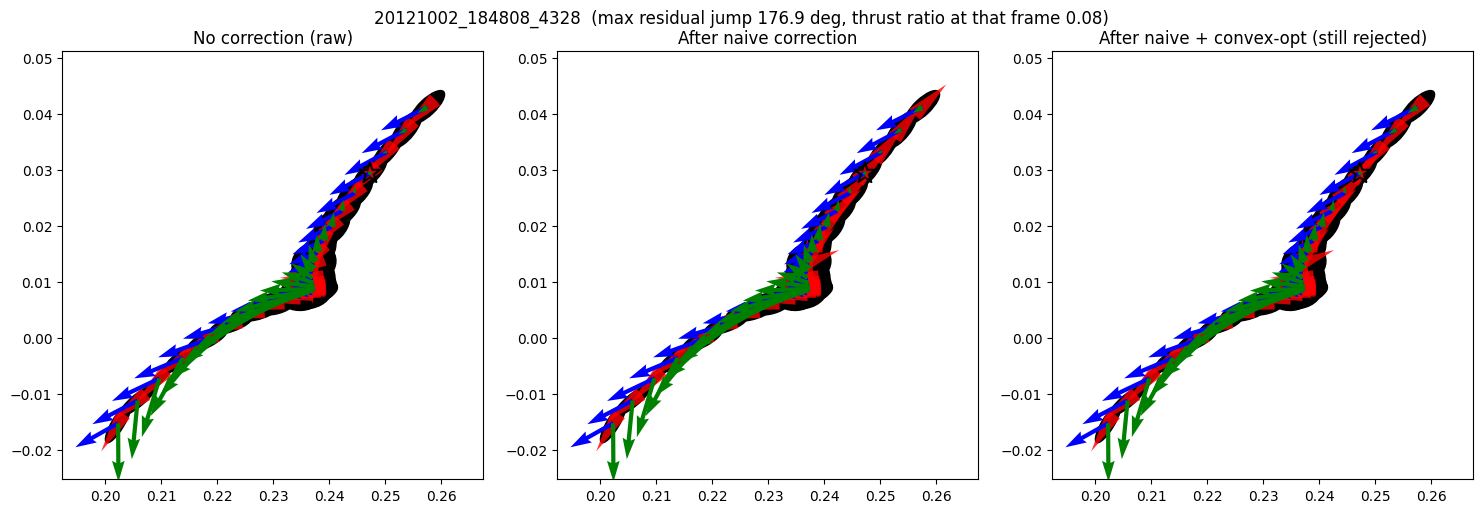

In [10]:
borderline_cases = fails_both.sort_values('final_max_jump_deg').head(4)
print(borderline_cases[['trajec_objid', 'n_frames', 'naive_max_jump_deg', 'final_max_jump_deg',
                        'thrust_ratio_at_worst_frame']].to_string(index=False))

plot_kwargs = dict(heading_color='red', heading_size=0.3, every_nth=1,
                   arrow_width=0.010, arrow_scale=0.7, legend=False)

for _, row in borderline_cases.iterrows():
    tid = row['trajec_objid']
    raw_group = augmented_02[augmented_02['trajec_objid'] == tid].copy()
    naive_group = naive_heading_correction(raw_group.copy())
    final_group = groups_03[tid]

    final_diff = calc_circular_difference(final_group)
    worst_idx = final_diff['circ_dist_diff'].idxmax()
    worst_x = final_group.loc[worst_idx, 'position_x']
    worst_y = final_group.loc[worst_idx, 'position_y']

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=100)
    plot_trajectory(axs[0], raw_group, **plot_kwargs)
    axs[0].set_title('No correction (raw)')
    plot_trajectory(axs[1], naive_group, **plot_kwargs)
    axs[1].set_title('After naive correction')
    plot_trajectory(axs[2], final_group, **plot_kwargs)
    axs[2].set_title('After naive + convex-opt (still rejected)')
    for ax in axs:
        ax.scatter([worst_x], [worst_y], marker='*', s=250, facecolor='none',
                  edgecolor='black', linewidths=1.5, zorder=5)
    fig.suptitle(f"{tid}  (max residual jump {row['final_max_jump_deg']:.1f} deg, "
                f"thrust ratio at that frame {row['thrust_ratio_at_worst_frame']:.2f})")
    fig.tight_layout()
    os.makedirs('../figures/reviewer_response_part9_borderline_rejections', exist_ok=True)
    fig.savefig(f"../figures/reviewer_response_part9_borderline_rejections/{tid}.png", format='png', dpi=100)
    plt.show()
    plt.close(fig)

**Significance:** these 4 examples are the *only* part of the 1,001 rejections
where naive-only itself already failed (Section 4's n=5 group), and they are a tiny,
atypical minority (0.5% of all rejections) - the dominant story, established in
Sections 3b-3d above, is the 996 trajectories convex-opt breaks that naive-only had
already gotten right.

## 7. Summary

**Direct answer: the pi/2 filter is not too strict. Convex-opt is ruining previously-fine
trajectories, and it accounts for essentially all of the 30% rejection rate.**

- **996 of 1,001 rejected trajectories (99.5%)** were completely fine after naive-only
  correction (max residual jump under 90 degrees) and were rejected specifically
  because the convex-opt step introduced a large jump. Naive-only correction alone would
  retain 3,334 of 3,339 candidates (99.85%); it is specifically convex-opt that drives
  the retention rate down to 70%.
- **Convex-opt rescued zero trajectories** that were failing at the naive-only stage.
  Only 5 of 1,001 rejections (0.5%) are cases naive-only genuinely could not resolve on
  its own, and even most of those look more like additional optimizer instability than
  unresolvable raw data (Section 4).
- The 996 introduced jumps are overwhelmingly **near-complete 180 degree flips** (median
  173.8 degrees, 60% above 170 degrees), not marginal nudges across the threshold, and
  78% occur at **below-average thrust** for that trajectory - the opposite of what the
  thrust-alignment term's design rationale would predict for a real high-force
  correction event.
- Direct visual inspection (Section 3d, unwrapped heading vs. frame index - the
  diagnostic that actually works, after spatial trajectory plots proved too subtle to
  judge by eye in both this notebook and Part 8) shows convex-opt: (a) disagreeing with
  a smooth, stable naive-only signal for an isolated stretch of frames and then flipping
  back with no physical basis, (b) becoming unstable specifically at trajectory
  boundaries (consistent with the current production function no longer anchoring `k=0`
  at trajectory ends, unlike the pre-merge buggy version), and (c) in the longest
  example tested, disagreeing with naive-only across nearly the entire trajectory from
  frame zero.

**Practical implication:** this is a strong, well-powered case that the convex-opt
correction step, as currently configured (`alpha1=1`, `alpha2=5`, no boundary anchor),
is net harmful to trajectory retention - it discards roughly 30% of otherwise-usable
data by introducing flips that a much simpler naive-only heuristic does not make. This
is a different and more actionable finding than Part 7's pooled accuracy comparison (a
small, real, but partial benefit on the trajectories that survive): among the full
candidate pool, before filtering, convex-opt's cost in discarded good data appears to
outweigh its benefit on the data it does not ruin. Reintroducing a boundary anchor
and/or revisiting the alpha1/alpha2 balance (or thrust-magnitude normalization at the
trajectory level) would be the natural next things to try, and could plausibly recover
most of the 996 trajectories currently being discarded unnecessarily.

New artifacts: `pipelinedata/reviewer_response/rejection_cause_analysis.csv`,
`figures/reviewer_response_part9_rejection_cause.svg`,
`figures/reviewer_response_part9_naive_vs_final_scatter.svg`,
`figures/reviewer_response_part9_timeseries_diagnostic.svg`,
`figures/reviewer_response_part9_convex_caused_rejections/*.png`,
`figures/reviewer_response_part9_borderline_rejections/*.png`.
